# Illustrative example of exception-rule analysis

This notebook presents the complete analysis workflow: data preparation, CR–RR–ER rule induction, selection of an example rule, and interpretation of its coverage using several complementary visualizations. **CR** denotes a commonsense rule, **RR** a reference rule, and **ER** an exception rule.

## 1. Loading and preparing the data

We load the `anneal.csv` dataset and separate the decision attribute, `class`, from the attributes describing the examples. The `X` data frame will be used to induce conditions, while `y` contains the expected classes.

In [16]:
import pandas as pd
df = pd.read_csv("../../../mushroom.csv")
X = df.drop(columns=["class"])
y = df["class"]

## 2. Configuring the algorithm

We create an exception-rule classifier. Its parameters control aspects such as minimum coverage, the quality measure, rule pruning, and exception discovery. This example uses the configuration passed to the constructor below.

In [17]:
from exception_rules.classification.algorithm import ExceptionRulesClassifier

generator = ExceptionRulesClassifier()

## 3. Inducing the model

The `fit` method discovers rules from the training data. It returns a fitted model containing the rule set and the stored data subsequently required for coverage analysis and visualization.

In [18]:
model = generator.fit(X , y)

## 4. Reviewing the discovered rules

We display the rules together with their coverage information. For rules with an exception, the complete CR–RR–ER triple is shown. Pay attention to the conditions, the numbers of covered positive and negative examples, and the class for which the exception was formulated. The `only_with_exceptions=True` option limits the output to rules that have exceptions.

In [19]:
model.print_rules()

Rule 1: IF odor = {f} THEN class = p (p=2160, n=0, P=3916, N=4208)
Rule 2: IF gill-color = {b} THEN class = p (p=1728, n=0, P=3916, N=4208)
Rule 3: IF stalk-surface-above-ring = {k} THEN class = p (p=2228, n=144, P=3916, N=4208)
Rule 4: IF gill-size = {n} THEN class = p (p=2224, n=288, P=3916, N=4208)
Exception Rule 4: IF gill-size = {n} AND spore-print-color = {h} THEN class = e (p=48, n=0, P=4208, N=3916)
Reference Rule 4: IF spore-print-color = {h} THEN class = p (p=1584, n=48, P=3916, N=4208)
Rule 5: IF spore-print-color = {r} THEN class = p (p=72, n=0, P=3916, N=4208)
Rule 6: IF odor = {n} THEN class = e (p=3408, n=120, P=4208, N=3916)
Exception Rule 6: IF odor = {n} AND stalk-root = {c} THEN class = p (p=8, n=0, P=3916, N=4208)
Reference Rule 6: IF stalk-root = {c} THEN class = e (p=512, n=44, P=4208, N=3916)
Rule 7: IF odor = {a} THEN class = e (p=400, n=0, P=4208, N=3916)
Rule 8: IF odor = {l} THEN class = e (p=400, n=0, P=4208, N=3916)


## 5. Selecting the rule to analyze

For further analysis, we select the eighth rule (index `7`, because indexing starts at zero). The selected CR should have both `reference_rule` and `exception_rule` assigned; all subsequent plots concern this same triple.

In [20]:
rule = model.ruleset.rules[3]

## 6. Examples covered by CR, RR, and ER

The three tables below show the original feature values and target class separately for examples covered by CR, RR, and ER. Because rule coverage may overlap, the same dataset example can appear in more than one table.

Each interactive table provides pagination, sorting, filtering, and horizontal scrolling. Use the page-length menu to display 10, 25, 50, or 100 rows at a time.

In [21]:
from itables import show

cr_X, cr_y = model.get_covered_examples(rule)
cr_examples = pd.DataFrame(cr_X, columns=model.columns_names)
cr_examples[model.label_name] = cr_y
show(cr_examples, paging=True, pageLength=10, lengthMenu=[10, 25, 50, 100], scrollX=True)

In [22]:
rr_X, rr_y = model.get_covered_examples(rule.reference_rule)
rr_examples = pd.DataFrame(rr_X, columns=model.columns_names)
rr_examples[model.label_name] = rr_y
show(rr_examples, paging=True, pageLength=10, lengthMenu=[10, 25, 50, 100], scrollX=True)

In [23]:
er_X, er_y = model.get_covered_examples(rule.exception_rule)
er_examples = pd.DataFrame(er_X, columns=model.columns_names)
er_examples[model.label_name] = er_y
show(er_examples, paging=True, pageLength=10, lengthMenu=[10, 25, 50, 100], scrollX=True)

## 7. Attribute distributions of covered examples

Each panel compares examples covered by the CR, RR, and ER. Histograms are displayed for numerical attributes and category counts for nominal attributes. Differences in location, spread, or dominant categories indicate features that distinguish the exception. `all_attributes=True` displays the complete feature set, while `compact=True` arranges the panels in a compact grid. Coverage sets may overlap, so group sizes do not necessarily sum to the number of records.

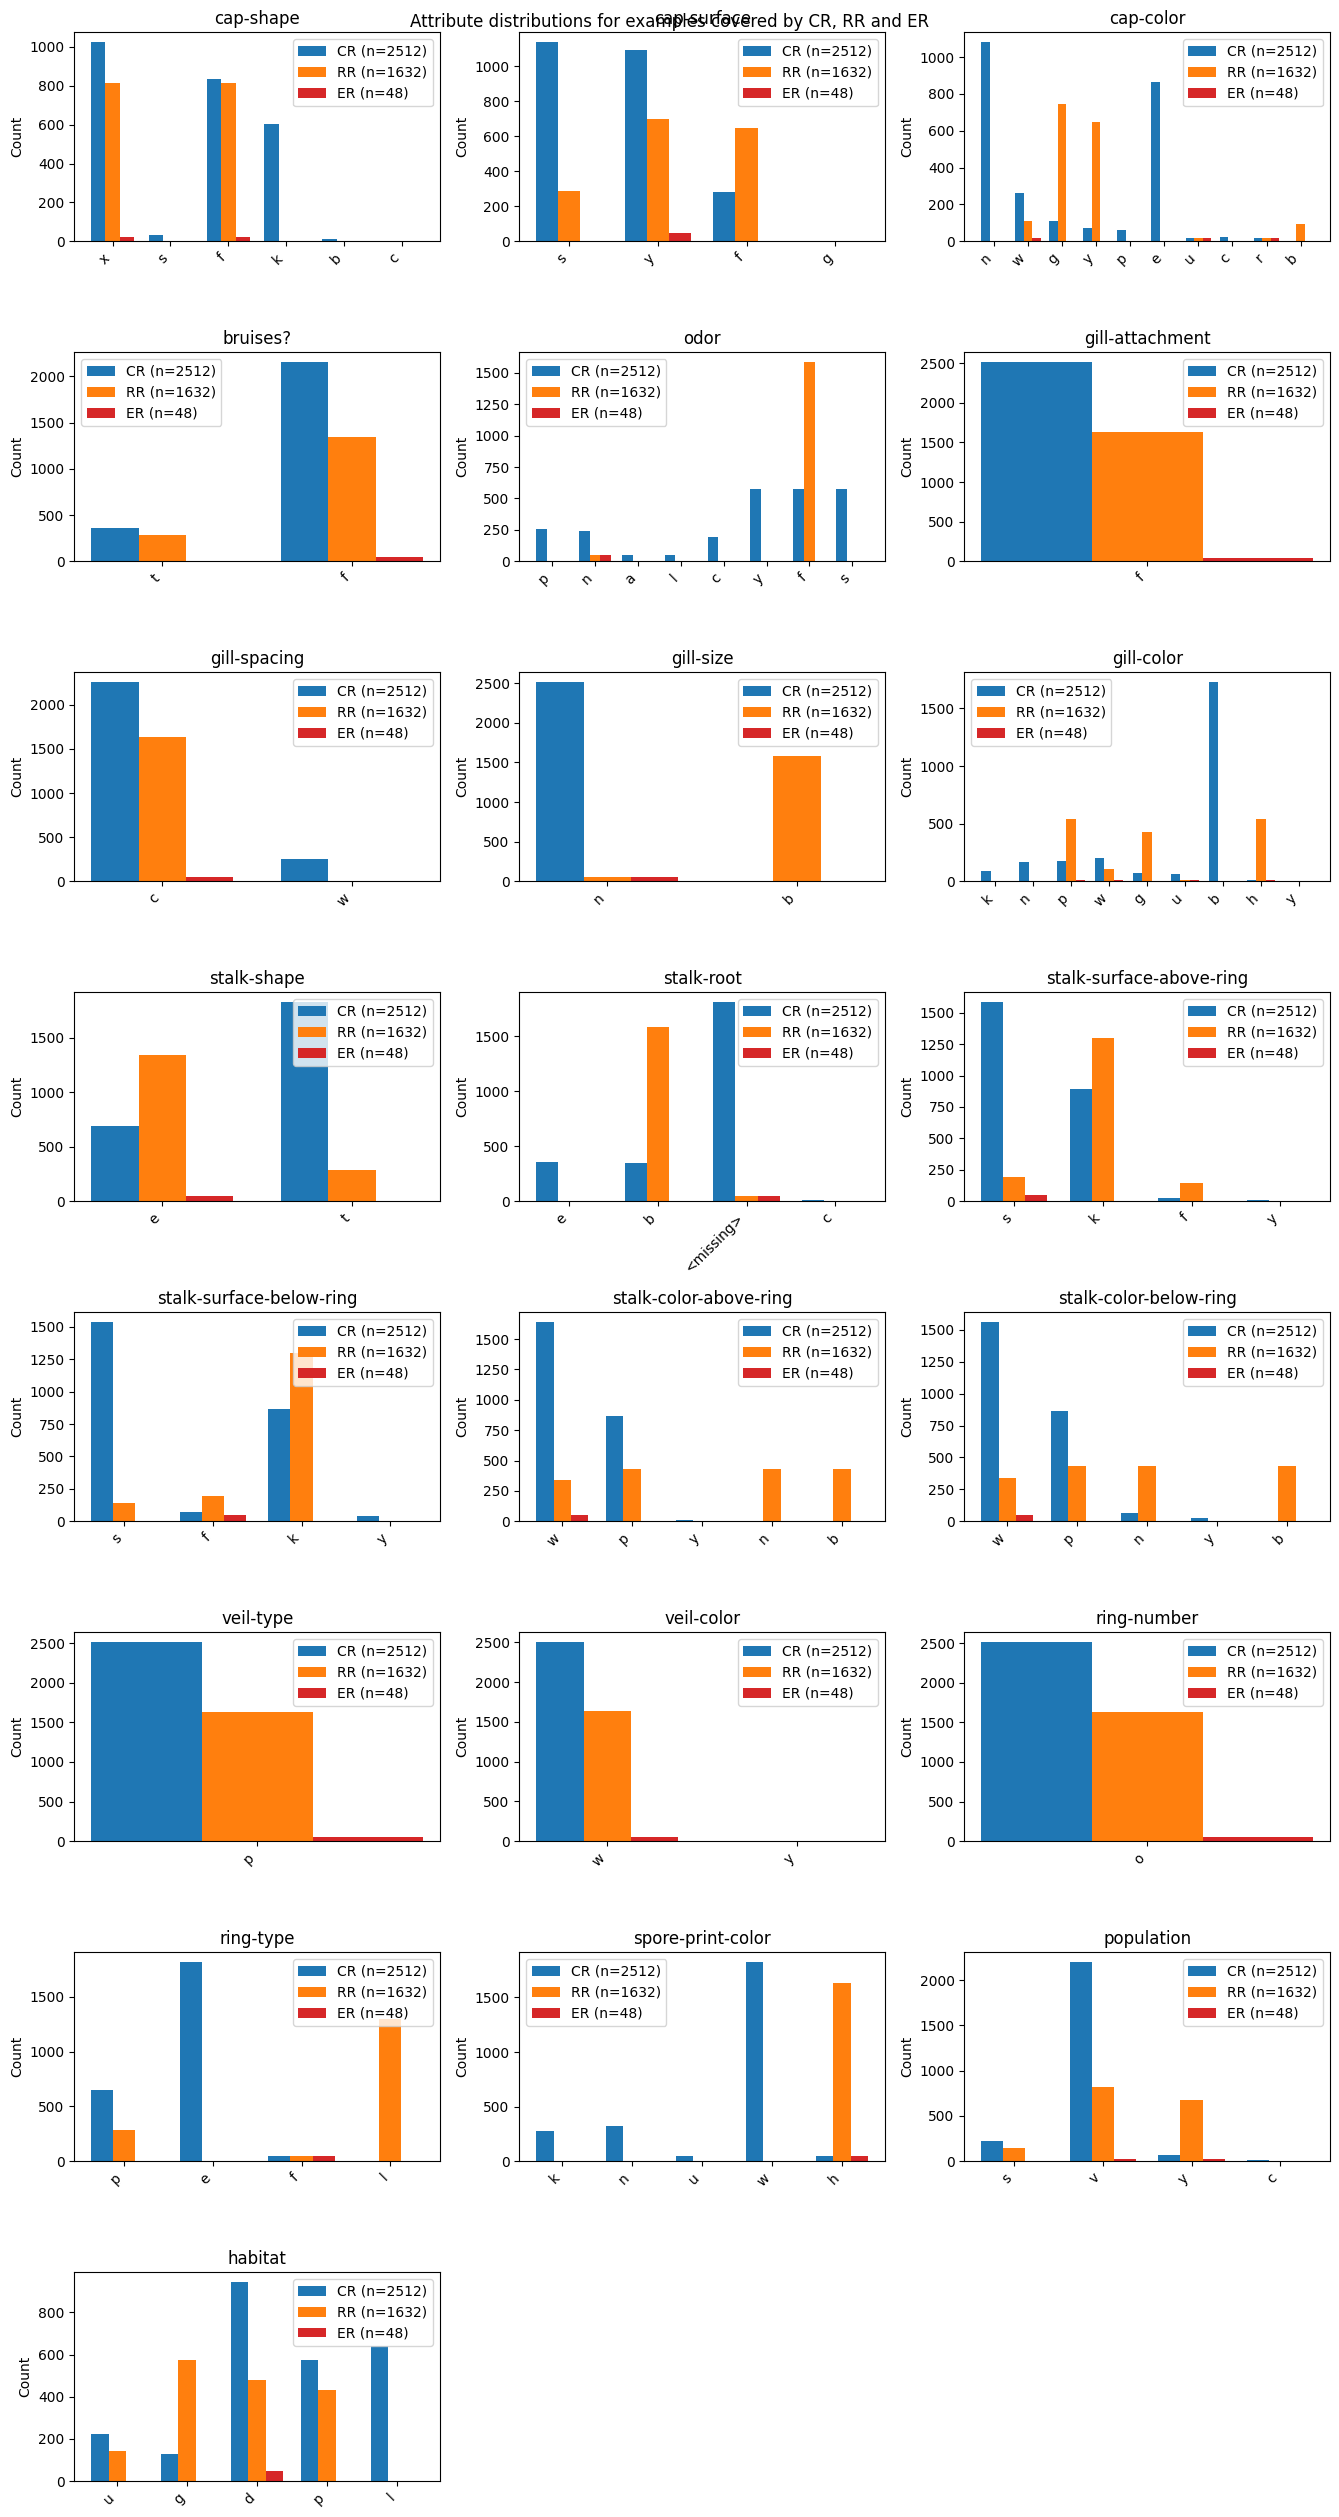

(<Figure size 1350x2560 with 24 Axes>,
 array([<Axes: title={'center': 'cap-shape'}, ylabel='Count'>,
        <Axes: title={'center': 'cap-surface'}, ylabel='Count'>,
        <Axes: title={'center': 'cap-color'}, ylabel='Count'>,
        <Axes: title={'center': 'bruises?'}, ylabel='Count'>,
        <Axes: title={'center': 'odor'}, ylabel='Count'>,
        <Axes: title={'center': 'gill-attachment'}, ylabel='Count'>,
        <Axes: title={'center': 'gill-spacing'}, ylabel='Count'>,
        <Axes: title={'center': 'gill-size'}, ylabel='Count'>,
        <Axes: title={'center': 'gill-color'}, ylabel='Count'>,
        <Axes: title={'center': 'stalk-shape'}, ylabel='Count'>,
        <Axes: title={'center': 'stalk-root'}, ylabel='Count'>,
        <Axes: title={'center': 'stalk-surface-above-ring'}, ylabel='Count'>,
        <Axes: title={'center': 'stalk-surface-below-ring'}, ylabel='Count'>,
        <Axes: title={'center': 'stalk-color-above-ring'}, ylabel='Count'>,
        <Axes: title={'cent

In [24]:
model.plot_covered_examples_distributions(rule, all_attributes=True,compact = True)

## 8. PCA projection

PCA reduces multidimensional data to two directions while retaining as much variance as possible. Colors and marker shapes indicate CR, RR, and ER coverage, while gray points denote uncovered examples. A separate ER cluster suggests a distinctive exception profile; overlapping points indicate similarity in the analyzed space. The percentages on the axes report how much of the total variance is retained by the projection. PCA is unsupervised and does not deliberately attempt to separate ER examples.

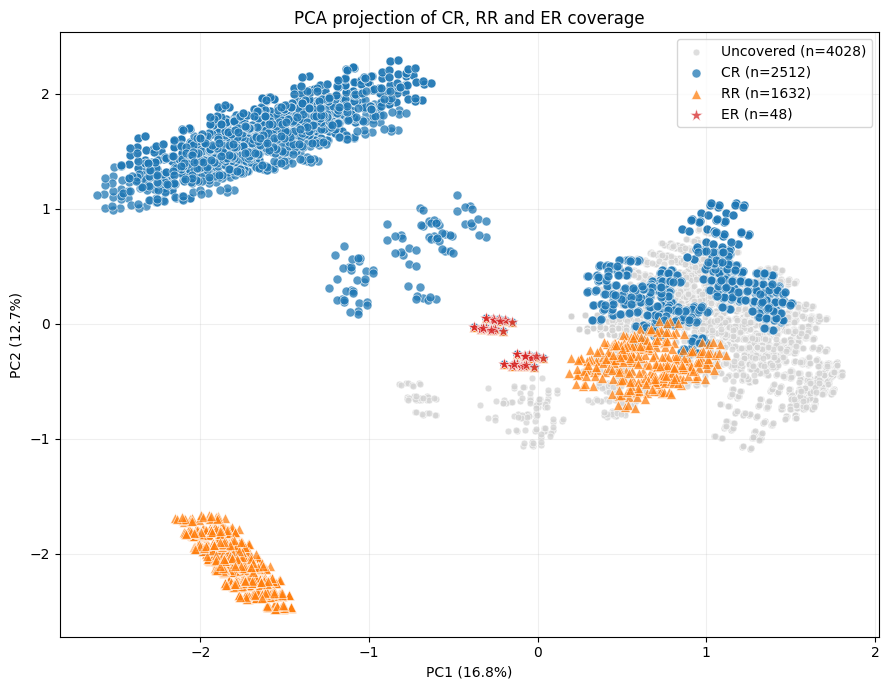

(<Figure size 900x700 with 1 Axes>,
 <Axes: title={'center': 'PCA projection of CR, RR and ER coverage'}, xlabel='PC1 (16.8%)', ylabel='PC2 (12.7%)'>)

In [25]:
model.plot_rule_pca(rule, all_attributes=True)

## 9. Separation of exception examples

The LDA plot presents the distributions of ER and non-ER examples on a single axis selected to separate these groups as effectively as possible. Little overlap between the histograms indicates strong separation, whereas substantial overlap indicates the absence of a clear linear distinction. Bar height represents density, not the number of records. Because LDA is supervised and uses the ER label, the training-data result should be treated as a diagnostic rather than independent evidence of generalization.

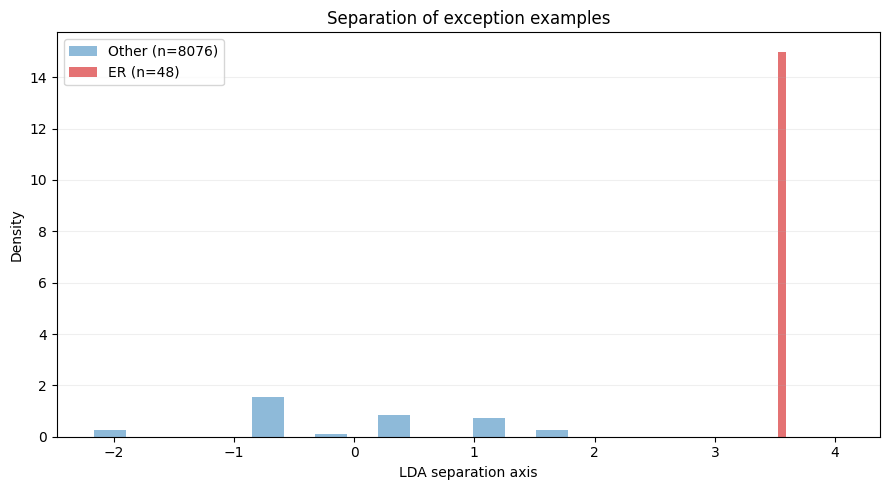

(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Separation of exception examples'}, xlabel='LDA separation axis', ylabel='Density'>)

In [26]:
model.plot_exception_separation(
    rule,
    all_attributes=False,
    bins=15,
)

## 10. The exception within its immediate neighborhood

This plot compares ER examples with CR excluding ER and RR excluding ER. An empirical cumulative distribution function (ECDF) is used for numerical features, while nominal features show the proportion of each category. Greater distances between ECDF curves or larger differences in bar height indicate that an attribute more strongly distinguishes the exception from its immediate context.

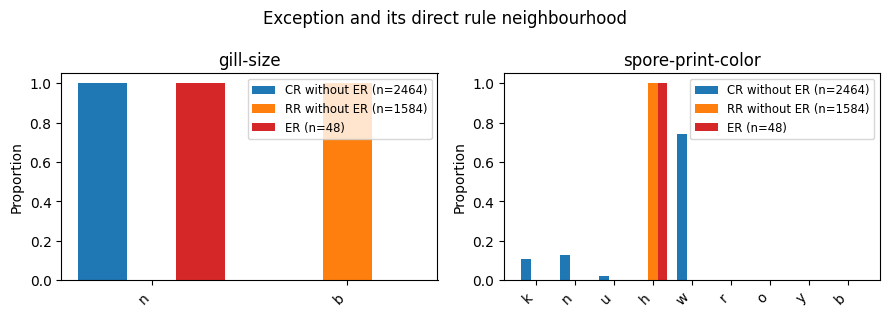

(<Figure size 900x320 with 2 Axes>,
 array([<Axes: title={'center': 'gill-size'}, ylabel='Proportion'>,
        <Axes: title={'center': 'spore-print-color'}, ylabel='Proportion'>],
       dtype=object))

In [27]:
model.plot_exception_neighborhood(rule)

## 11. Parallel coordinates

Each line represents one example, and successive axes represent transformed attributes. A consistent pattern among the red ER lines that differs from CR and RR reveals a multidimensional exception profile and interactions among features. Nominal attributes are one-hot encoded, so a single feature may correspond to several axes. For large datasets, a representative sample is displayed to reduce overplotting.

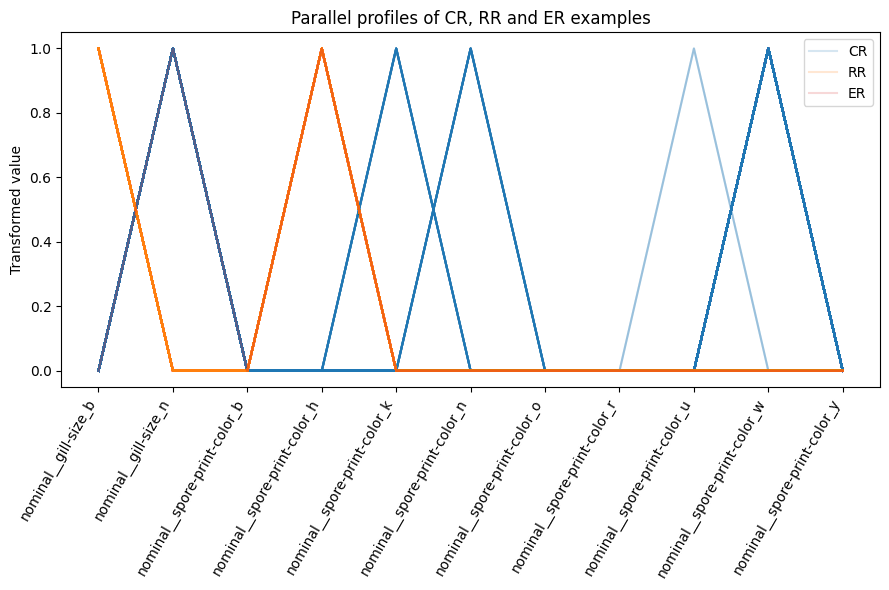

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Parallel profiles of CR, RR and ER examples'}, ylabel='Transformed value'>)

In [28]:
model.plot_rule_parallel_coordinates(rule)

## 12. Boxplots of numerical attributes

The boxplots compare the median, quartiles, spread, and outliers of numerical features across CR, RR, and ER. A shifted ER box indicates a different typical feature value, while a smaller box indicates greater homogeneity among exception examples. This plot omits nominal features; if the exception rule contains only nominal features, use the distribution or neighborhood plot instead.

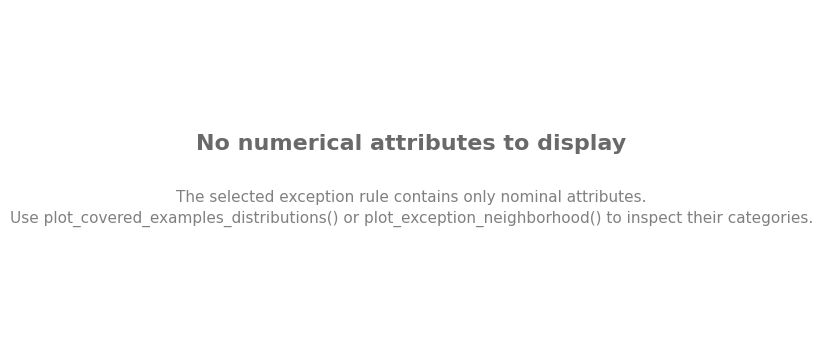

(<Figure size 800x350 with 1 Axes>, array([<Axes: >], dtype=object))

In [29]:
model.plot_rule_boxplots(rule)

## 13. Heatmap of attribute profiles

Rows correspond to examples ordered by the CR → RR → ER groups, while columns represent encoded and scaled features. Color indicates the transformed value. A uniform color block in the ER section denotes a consistent exception profile, whereas an abrupt color change relative to earlier rows identifies an attribute responsible for the difference. For one-hot features, values indicate the absence or presence of a category.

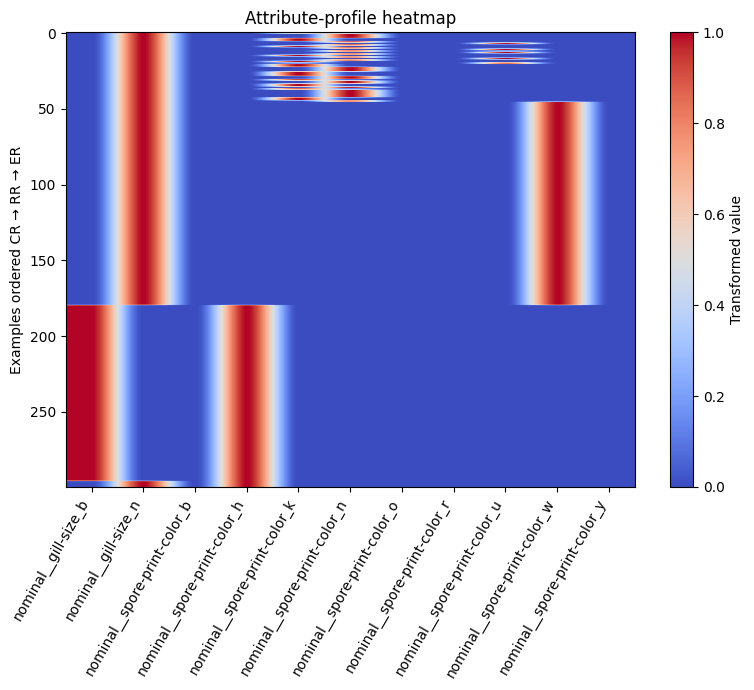

(<Figure size 800x700 with 2 Axes>,
 <Axes: title={'center': 'Attribute-profile heatmap'}, ylabel='Examples ordered CR → RR → ER'>)

In [30]:
model.plot_rule_heatmap(rule)

## 14. Coverage matrix

Each row represents an example, and the three columns indicate whether it is covered by CR, RR, and ER. A blue cell denotes coverage and a white cell its absence. Rows are grouped by coverage pattern, making it easier to assess rule nesting and detect unusual relationships, such as ER covering records outside CR or RR.

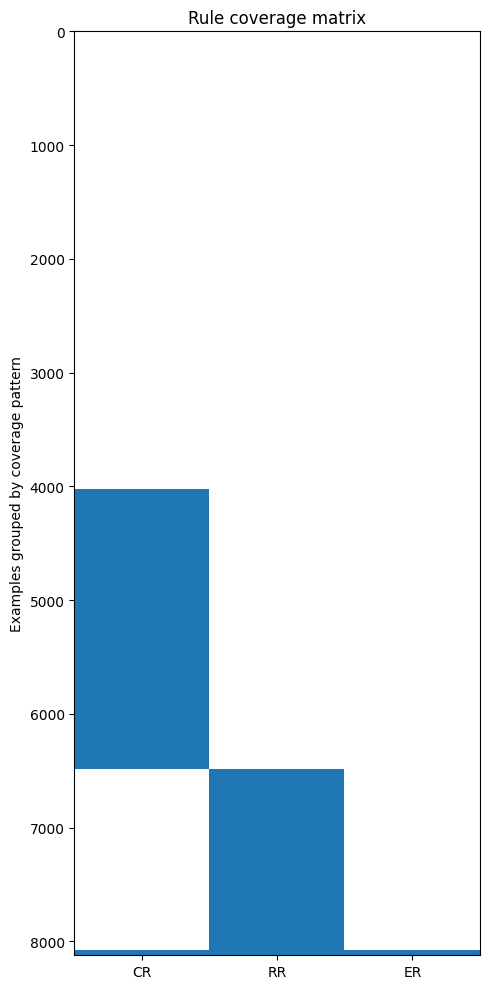

(<Figure size 500x1000 with 1 Axes>,
 <Axes: title={'center': 'Rule coverage matrix'}, ylabel='Examples grouped by coverage pattern'>)

In [31]:

model.plot_rule_coverage_matrix(rule)

## 15. CR–RR–ER coverage intersections

The UpSet-style chart summarizes exact rule intersections. The upper bars give the number of examples for each pattern, while the lower dot matrix identifies the rules forming that intersection; connected black dots indicate joint coverage. The plot makes it possible to verify numerically whether ER is a subset of the expected region and how large the portions covered exclusively by CR or RR are.

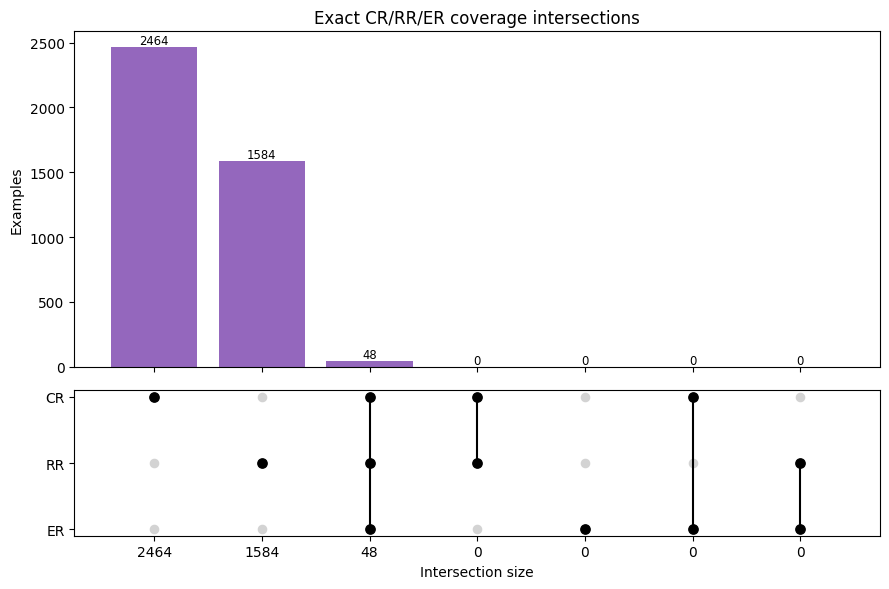

(<Figure size 900x600 with 2 Axes>,
 array([<Axes: title={'center': 'Exact CR/RR/ER coverage intersections'}, ylabel='Examples'>,
        <Axes: xlabel='Intersection size'>], dtype=object))

In [32]:
model.plot_rule_coverage_intersections(rule)